In [116]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [117]:
df=pd.read_csv(r"C:\Users\Dhruv\Downloads\Churn_Modelling (1).csv")
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [118]:
# Data Cleaning
df['Gender']=df['Gender'].replace({'Male':0,'Female':1})

C:\Users\Dhruv\AppData\Local\Temp\ipykernel_3960\820585778.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender']=df['Gender'].replace({'Male':0,'Female':1})


In [119]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [120]:
# Feature election
X=df[['CreditScore','Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember','EstimatedSalary']]
y=df[['Exited']]

In [121]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [122]:
# Model Selection Decision tree
model=DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

In [123]:
# Model Trannning
model.fit(X_train,y_train)
pred=model.predict(X_test)

In [124]:
# Accuracy score
accuracy=accuracy_score(y_test,pred)
print("Accuracy Score:",accuracy*100)

Accuracy Score: 85.66666666666667


In [136]:
# Feature Importances
feature_importances_ =model.feature_importances_
print("Feature Importance:",feature_importances_)

Feature Importance: [9.49578420e-03 4.09881123e-04 4.39593711e-01 3.46702667e-03
 3.28967860e-02 3.36306057e-01 0.00000000e+00 1.65152756e-01
 1.26779980e-02]


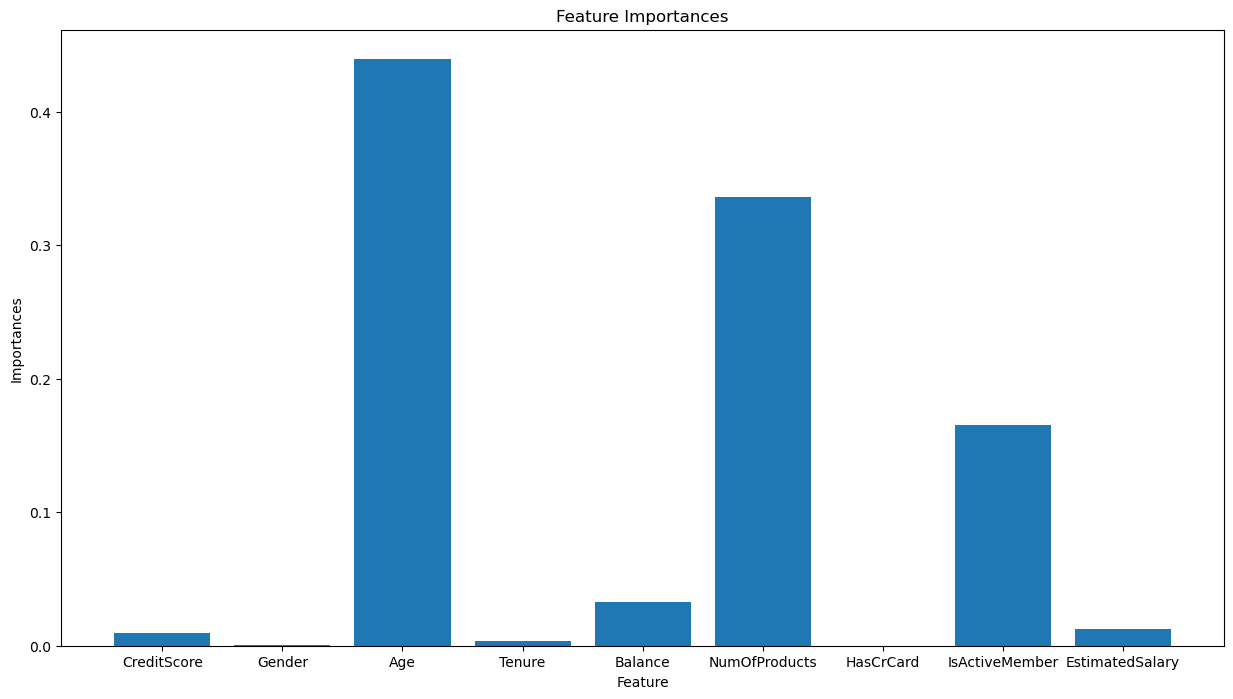

In [182]:
# Graphical Representation
plt.figure(figsize=(15,8))
plt.bar(
    X.columns,
    feature_importances_
)
plt.xlabel('Feature')
plt.ylabel('Importances')
plt.title("Feature Importances")
plt.show()

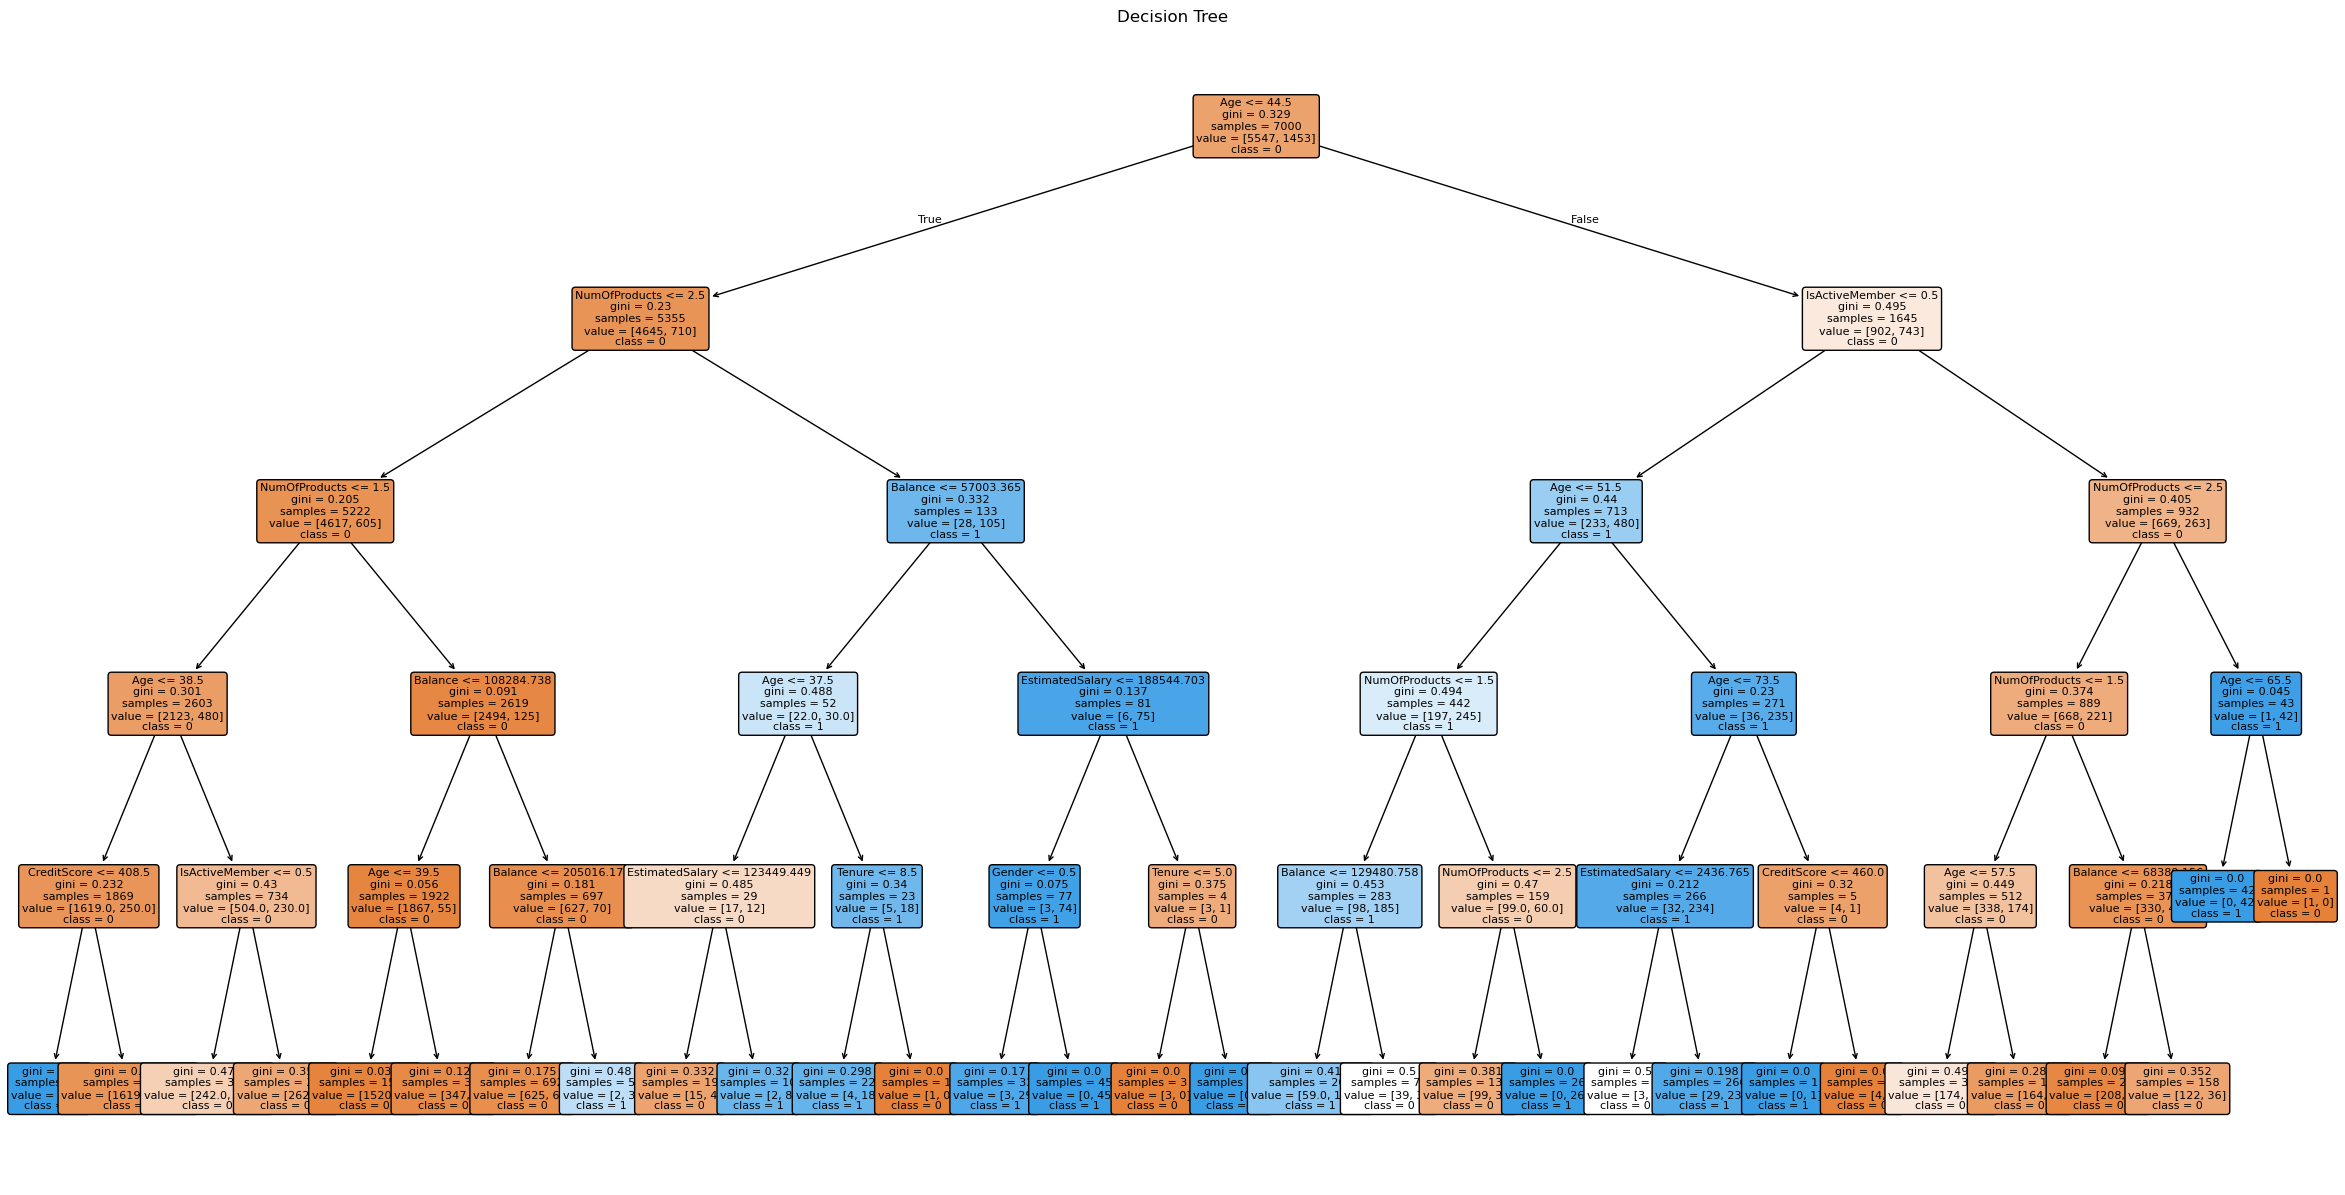

In [200]:
# Visulization for decision tree
plt.figure(figsize=(30,15))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['0','1'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree')
plt.show()